In [1]:
#Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from matplotlib.ticker import FormatStrFormatter
import os
import re

# Normalizar Vdiodo entre -1 y 1
def normalize(data):
    range = np.ptp(data['Vdiodo'])
    data['DVdiodo'] = data['Vdiodo'] - np.min(data['Vdiodo']) - range / 2
    data['Mnorm'] = (((data['Vdiodo'] - np.min(data['Vdiodo'])) / range) * 2) - 1

# Función que
def cubic_spline_opt(x_data, y_data):
    def func(x, s):
        spline = UnivariateSpline(x_data, y_data, s=s)  # s=suavizado: más alto = más liso, s=0 interpola exactamente
        return spline(x)
    return func

# Suavizado de datoss
def smooth(y, box_pts):
    padded_data = np.pad(y, (box_pts//2, box_pts//2), mode='reflect')
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(padded_data, box, mode='valid')
    return y_smooth

# Lineal
def lineal(x, a, b):
    return x * a + b

def spline_length(grupo):
    if grupo == '15nm':
        return 0.1
    if grupo == '24nm':
        return 0.2
    if grupo == '55nm':
        return 0.2
    if grupo == '158nm':
        return 0.4

    return 0.1

dir = "datos/muestras/"
dirs = os.listdir(dir)
print(dirs)

['39nm', '55nm', '24nm', '158nm', '15nm']


In [2]:
# Estilos 
plt.rcParams.update({
    "font.family": "CMU Serif",
    "font.weight":'medium'
})

def python_style_st(x = 'ejex', y = 'ejey', titulo = None, both = True):
    # sns.set_theme()
    plt.grid(True, linestyle='--', alpha=0.8)
    plt.xlabel(x, fontsize = 15)
    plt.ylabel(y, fontsize = 15)
    if both:
        plt.tick_params(axis="both", direction = "in")
    else:
        plt.tick_params(direction = "in")
    plt.title(titulo)
    plt.xticks(fontsize = 13)
    plt.yticks(fontsize = 13)


def python_style_end():
    plt.tight_layout()
    

In [3]:
#Análisis de datos
def analizar_datos(file_dir):
    rama = ['bajada', 'subida']
    contador = 0
    data = pd.read_csv(file_dir, sep = '\t')

    data['B'] = data['B'] - data['B'].iloc[0] ## Desplazo todos los valores de campo
    data['t'] = data['t'] - data['t'].iloc[0]

    filename = re.findall(r'([^/]+)\.dat', file_dir)[0]

    normalize(data)

    dif_i = np.diff(data['I_fuente'])
    signo_dif_i = np.sign(dif_i)

    # Detectar cambios de signo (esquinas del lazo de histéresis)
    cambios = np.where(signo_dif_i[1:] != signo_dif_i[:-1])[0] + 1

    # Cortar el DataFrame en segmentos
    segmentos = np.split(data.to_numpy(), cambios)
    segmentos = [pd.DataFrame(d, columns=data.columns) for d in segmentos]

    raices = np.empty(0)

    data['tipo'] = 'comienzo'

    for subdata in segmentos[-3:]:
        if len(subdata) < 10:
            continue

        data.loc[data['t'].isin(subdata['t']), 'tipo'] = rama[contador]
        contador += 1

        x = subdata['B']
        y = subdata['DVdiodo']

        root = 0
        for i in range(len(y) - 1):
            if y[i] * y[i+1] < 0:
                x0, x1 = x[i], x[i+1]
                y0, y1 = y[i], y[i+1]
                root = x0 - y0 * (x1 - x0) / (y1 - y0)
                
        raices = np.append(raices, root)

    izq = raices[0]
    der = raices[1]

    diff_2 = (der - izq) / 2
    ## -izq lo lleva al 0 - diff / 2 lo centra
    offset = -diff_2 - izq

    data['B'] = data['B'] + offset
    data['Hc'] = diff_2
    
    ## Guardar datos
    # plt.plot(data['B'], data['Vdiodo'])
    data.to_csv('datos_analizados/' + filename + '.csv', sep = '\t')
    # raices

def analizar_todos(data_dir):
    files = os.listdir(data_dir)
    for file in files:
        if not file.__contains__('.dat'):
            continue
        file_dir = data_dir + '/' + file
        analizar_datos(file_dir)

def calc_dist(name):
    dir = 'datos_analizados/'

    files = os.listdir(dir)

    Hc = np.empty(0)

    for file in files:
        if not file.__contains__(name):
            continue

        data = pd.read_csv(dir + file, sep = '\t')
        Hc = np.append(Hc, data['Hc'][0])

    return np.mean(Hc), np.std(Hc) / np.sqrt(len(Hc))

def errCampo(Campo):
    pen = 4.331286718960056
    err_pen = 0.006123006020318645

    err_V = 1e-4
    delta_V = Campo / pen

    return Campo * np.sqrt((err_V/delta_V)**2 + (err_pen/pen)**2)

        

In [4]:
## Ploteo de datos
def plotear_subida(datos, x_ax = 'B', y_ax = 'Mnorm', label = 'Subida', color = 'r'):
    subida = datos[datos['tipo'] == 'subida']   
    x = subida[x_ax]
    y = subida[y_ax] 
    plt.plot(x, y, label = label, color = color,
        linestyle = '--'     
        )


def plotear_bajada(datos, x_ax = 'B', y_ax = 'Mnorm', label = 'Bajada', color = 'b'):
    subida = datos[datos['tipo'] == 'bajada']   
    x = subida[x_ax]
    y = subida[y_ax] 
    plt.plot(x, y, label = label, color = color,
        linestyle = '--'     
        )

def plotear_datos_Mnrom(datos):
    python_style_st(x = r'$H_{ext} \ [mT]$', y = r'$M \ [u.a]$')

    # Datos medidos
    plt.scatter(datos['B'], datos['Mnorm'], label = 'Mediciones', marker = 'o', fc = 'none', edgecolors='gray', linewidths=2)

    # Ramas
    plotear_subida(datos, label = 'Rama de subida')
    plotear_bajada(datos, label = 'Rama de bajada')

    # Intersecciones
    _y = [0, 0]
    _x = [-datos['Hc'][0], datos['Hc'][0]]
    plt.scatter(_x, _y, label = r'$H_c$', marker = 'o', color = 'black', zorder = 2)

    plt.legend(fontsize = 13)
    python_style_end()

def plotear_datos_DVdiodo(datos):
    python_style_st(x = r'$H_{ext} \ [mT]', y = r'$\Delta V_d \ [mV]$')

    # Datos medidos
    plt.scatter(datos['B'], datos['DVdiodo'], label = 'Mediciones', marker = 'o', fc = 'none', edgecolors='gray', linewidths=2)

    # Ramas
    plotear_subida(datos, y_ax= 'DVdiodo', label = 'Rama de subida')
    plotear_bajada(datos, y_ax= 'DVdiodo', label = 'Rama de bajada')

    # Intersecciones
    _y = [0, 0]
    _x = [-datos['Hc'][0], datos['Hc'][0]]
    plt.scatter(_x, _y, label = r'$H_c$', marker = 'o', color = 'black', zorder = 2)

    # Legendas
    plt.legend(fontsize = 13)
    python_style_end()

def plotear_datos_Vdiodo_Vhall(datos):
    python_style_st(x = r'$V_H \ [mV]$', y = r'$V_d \ [mV]$')

    # Datos medidos
    plt.scatter(datos['Vhall'], datos['Vdiodo'], label = 'Mediciones', marker = 'o', fc = 'none', edgecolors='gray', linewidths=2)

    # Ramas
    plotear_subida(datos, x_ax='Vhall', y_ax= 'Vdiodo', label = 'Rama de subida')
    plotear_bajada(datos, x_ax='Vhall', y_ax= 'Vdiodo', label = 'Rama de bajada')

    # # Intersecciones
    # _y = [0, 0]
    # _x = [-datos['Hc'][0], datos['Hc'][0]]
    # plt.scatter(_x, _y, label = 'Hc', marker = 'o', color = 'black', zorder = 2)

    # Legendas
    plt.legend(fontsize = 13)
    python_style_end()

def plotear_dual_axis(datos):
    # Plotear normalizado en un lado y tensión en el otro
    python_style_st(x = r'$H_{ext} \ [mT]$', y = r'$M \ [u.a]$', both=False)

    # Datos medidos
    plt.scatter(datos['B'], datos['Mnorm'], label = 'Mediciones', marker = 'o', fc = 'none', edgecolors='gray', linewidths=2)

    ## Obtengo el axis utilizado
    ax1 = plt.gca()

    ## Agrego axis secundarios
    B = datos['B'].to_numpy()
    M = datos['Mnorm'].to_numpy()
    V_H = datos['Vhall'].to_numpy()
    V_d = datos['Vdiodo'].to_numpy()

    # Ordenar los arrays si no son monótonos (necesario para interp1d)
    idx_B = np.argsort(B)
    idx_M = np.argsort(M)
    
    # Crear funciones de interpolación para V_H y B
    B_to_VH = interp1d(B[idx_B], V_H[idx_B], fill_value="extrapolate")
    VH_to_B = interp1d(V_H[idx_B], B[idx_B], fill_value="extrapolate")

    # Crear funciones de interpolación para V_d y M
    M_to_Vd = interp1d(M[idx_M], V_d[idx_M], fill_value="extrapolate")
    Vd_to_M = interp1d(V_d[idx_M], M[idx_M], fill_value="extrapolate")

    # Ejes secundarios
    secax_top = ax1.secondary_xaxis('top', functions=(B_to_VH, VH_to_B))
    secax_top.set_xlabel(r"$V_H \ [mV]$", fontsize=15)
    secax_top.tick_params(axis="x", direction="in", labelsize=13)
    secax_top.xaxis.set_major_formatter(FormatStrFormatter('%.2f'))

    secax_left = ax1.secondary_yaxis('right', functions=(M_to_Vd, Vd_to_M))
    secax_left.set_ylabel(r"$V_d \ [mV]$", fontsize=15)
    secax_left.tick_params(axis="y", direction="in", labelsize=13)
    secax_left.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))


    # Ramas
    plotear_subida(datos, label = 'Rama de subida')
    plotear_bajada(datos, label = 'Rama de bajada')

    # Intersecciones
    _y = [0, 0]
    _x = [-datos['Hc'][0], datos['Hc'][0]]
    plt.scatter(_x, _y, label = r'$H_c$', marker = 'o', color = 'black', zorder = 2)

    plt.legend(fontsize = 13, loc = 'lower right')
    
    python_style_end()

def plotear_conj_datos(name, plot_fun, save = False, plot_comment = ''):
    dir = 'datos_analizados/'

    files = os.listdir(dir)

    for file in files:
        if not file.__contains__(name):
            continue

        try:
            data = pd.read_csv(dir + file, sep = '\t')
            #B [T] -> [mT]
            data['B'] = data['B'] * 1000
            data['Hc'] = data['Hc'] * 1000

            # V -> mV
            data['Vdiodo'] = data['Vdiodo'] * 1000
            data['Vhall'] = data['Vhall'] * 1000


            plot_fun(data)
            if save:
                plt.savefig('graficas/' + plot_comment + re.sub('.csv', '.png', file))
                plt.close()
            else:
                plt.show()
        finally:
            print('do nothing')


In [ ]:
# Crear datos analizados
# analizar_todos(dir + '/55nm')
# analizar_todos(dir + '/15nm')
# analizar_todos(dir + '/24nm')
# analizar_todos(dir + '/158nm')

In [72]:
#Plotear y guardar todo
plotear_conj_datos('15,8nm', plotear_datos_Mnrom, save = True, plot_comment='Mnorm')
plotear_conj_datos('158nm', plotear_datos_Mnrom, save = True, plot_comment='Mnorm')
plotear_conj_datos('55,3nm', plotear_datos_Mnrom, save = True, plot_comment='Mnorm')
plotear_conj_datos('24nm', plotear_datos_Mnrom, save = True, plot_comment='Mnorm')

plotear_conj_datos('15,8nm', plotear_datos_DVdiodo, save = True, plot_comment='DVdiodo')
plotear_conj_datos('158nm', plotear_datos_DVdiodo, save = True, plot_comment='DVdiodo')
plotear_conj_datos('55,3nm', plotear_datos_DVdiodo, save = True, plot_comment='DVdiodo')
plotear_conj_datos('24nm', plotear_datos_DVdiodo, save = True, plot_comment='DVdiodo')

plotear_conj_datos('15,8nm', plotear_datos_Vdiodo_Vhall, save = True, plot_comment='VHllDdo')
plotear_conj_datos('158nm', plotear_datos_Vdiodo_Vhall, save = True, plot_comment='VHllDdo')
plotear_conj_datos('55,3nm', plotear_datos_Vdiodo_Vhall, save = True, plot_comment='VHllDdo')
plotear_conj_datos('24nm', plotear_datos_Vdiodo_Vhall, save = True, plot_comment='VHllDdo')

plotear_conj_datos('15,8nm', plotear_dual_axis, save = True, plot_comment='Dual')
plotear_conj_datos('158nm', plotear_dual_axis, save = True, plot_comment='Dual')
plotear_conj_datos('55,3nm', plotear_dual_axis, save = True, plot_comment='Dual')
plotear_conj_datos('24nm', plotear_dual_axis, save = True, plot_comment='Dual')

do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing
do nothing

/home/atahualpa/Desktop/universidad/Balseiro/2do semestre/exp2/SMOKE/analisis/venv/lib/python3.12/site-packages/scipy/interpolate/_interpolate.py:479: RuntimeWarning: invalid value encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]


ValueError: Axis limits cannot be NaN or Inf

Error in callback <function _draw_all_if_interactive at 0x734b85bd1a80> (for post_execute), with arguments args (),kwargs {}:


ValueError: Axis limits cannot be NaN or Inf

ValueError: Axis limits cannot be NaN or Inf

<Figure size 640x480 with 1 Axes>

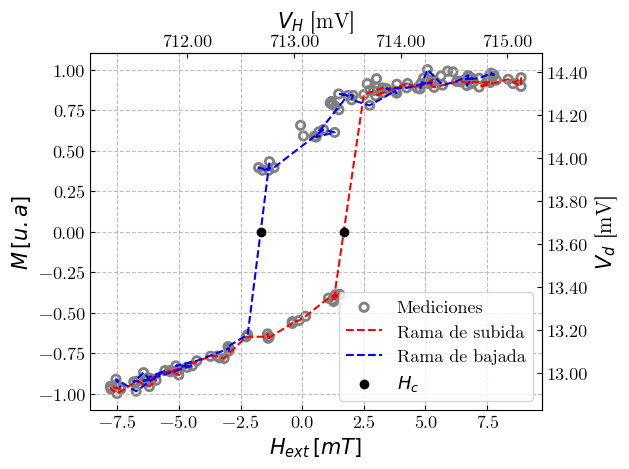

In [58]:
_datos = pd.read_csv('datos_analizados/medicion24nmCo35.csv', sep = '\t')

_datos['B'] = _datos['B'] * 1000
_datos['Hc'] = _datos['Hc'] * 1000

# V -> mV
_datos['Vdiodo'] = _datos['Vdiodo'] * 1000
_datos['Vhall'] = _datos['Vhall'] * 1000
plotear_dual_axis(_datos)
plt.show()

[np.float64(1.694884313652495), np.float64(1.8832865694987695), np.float64(2.394952296372475), np.float64(14.094219701922677)]
[0.0561581  0.05056829 0.23822631 0.74811704]


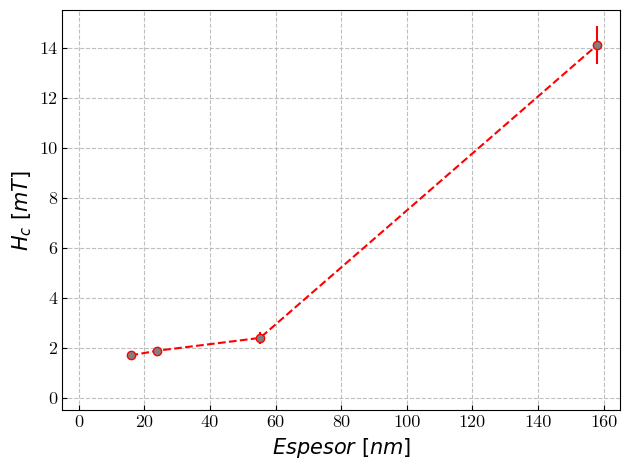

In [ ]:
espesores = [15.8, 24, 55.3, 158]
res_15 = calc_dist('15,8nm')
res_24 = calc_dist('24nm')
res_55 = calc_dist('55,3nm')
res_158 = calc_dist('158nm')
Hc = [res_15[0] * 1000, res_24[0] * 1000, res_55[0] * 1000, res_158[0] * 1000]
Err_Hc = [res_15[1] * 1000, res_24[1] * 1000, res_55[1] * 1000, res_158[1] * 1000]

print(Hc)

esp_lit = [8, 10, 20, 40, 60, 80, 100]
Hc_lit = [0.0021, 0.00225, 0.0025, 0.0027, 0.0028, 0.0039, 0.0042]

Err_Hc_inst = errCampo(np.array(Hc))
Err_Hc_final = np.sqrt(np.array(Err_Hc)**2 + Err_Hc_inst**2)
print(Err_Hc_final)

python_style_st(x = r'$Espesor \ [nm]$', y = r'$H_c \ [mT]$')
plt.errorbar(espesores, Hc, yerr= Err_Hc_final, marker = 'o', linestyle = '--', markerfacecolor='grey', color='red')
# plt.plot(esp_lit, Hc_lit)
plt.xlim(-5, 165)
plt.ylim(-0.5, 15.5)
python_style_end()
plt.savefig('campo_coercitivo_vs_espesor.png')
